# 03 - Model Training & Evaluation
---
**Objective:** Train and evaluate machine learning models

**Models:**
- Logistic Regression (baseline)
- Random Forest
- XGBoost
- LightGBM

**Metrics:**
- Precision, Recall, F1-Score
- ROC-AUC
- Confusion Matrix
- PR Curve

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Add project root to path
import os
import sys
sys.path.append(os.path.abspath('../'))
from src.data.loader import load_csv, save_file
from src.models.trainer import (
    split_data, encoding, class_weights, smote_oversampling, 
    clean_feature_names, undersampling
    )
from src.models.evaluator import evaluate_model, evaluate_threshold, plot_PR_curve

# Settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

print("Libraries imported successfully!")
print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
Python version: 3.13.5
Pandas version: 2.3.1
NumPy version: 2.3.2


In [16]:
# Load data
train = load_csv('../data/processed/train_final.csv')
print()
test = load_csv('../data/processed/test_final.csv')

👉 Loading: ../data/processed/train_final.csv
DATASET INFORMATION
Shape: 1,296,675 rows × 31 columns
Memory usage: 770.12 MB

Column types:
int64      13
float64    11
object      7
Name: count, dtype: int64

Missing values: 0

👉 Loading: ../data/processed/test_final.csv
DATASET INFORMATION
Shape: 555,719 rows × 31 columns
Memory usage: 330.06 MB

Column types:
int64      13
float64    11
object      7
Name: count, dtype: int64

Missing values: 0


## A. Prepare Data for Modeling

In [17]:
# Split data
X_train, y_train = split_data(train)
X_test, y_test = split_data(test)

In [18]:
# Clean feature names
X_train = clean_feature_names(X_train)
X_test = clean_feature_names(X_test)

In [19]:
# Encode categorical features
X_train, X_test = encoding(X_train, X_test)

Feature shape: (1296675, 30)


In [20]:
# Handle imbalance (class weight)
scale_pos_weight = class_weights(y_train)

scale_pos_weight: 171.75


In [21]:
# SMOTE oversampling
X_smote, y_smote = smote_oversampling(X_train, y_train)

After SMOTE:
is_fraud
0    1289169
1     257833
Name: count, dtype: int64


In [22]:
# Undersampling
X_under, y_under = undersampling(X_train, y_train, strategy=0.1)

After undersampling:
is_fraud
0    75060
1     7506
Name: count, dtype: int64


## B. Train Models

In [9]:
# Logistic Regression (Baseline)
lr_model = LogisticRegression(max_iter=200, class_weight='balanced')
lr_model.fit(X_train, y_train)

evaluate_model(lr_model, X_test, y_test, "Logistic Regression")


🔹 Logistic Regression
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98    553574
           1       0.08      0.74      0.14      2145

    accuracy                           0.96    555719
   macro avg       0.54      0.85      0.56    555719
weighted avg       1.00      0.96      0.98    555719

ROC-AUC: 0.842850107413472
PR-AUC: 0.14017286500796314
Confusion Matrix:
[[534452  19122]
 [   549   1596]]


In [23]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight={0: 1, 1: 50},
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

evaluate_model(rf_model, X_test, y_test, "Random Forest")


🔹 Random Forest
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.94      0.05      0.10      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.53      0.55    555719
weighted avg       1.00      1.00      0.99    555719

ROC-AUC: 0.8795882910409605
PR-AUC: 0.07668314146613321
Confusion Matrix:
[[553567      7]
 [  2037    108]]


In [10]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_under, y_under)

evaluate_model(xgb_model, X_test, y_test, "XGBoost")


🔹 XGBoost
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.08      0.24      0.12      2145

    accuracy                           0.99    555719
   macro avg       0.54      0.61      0.55    555719
weighted avg       0.99      0.99      0.99    555719

ROC-AUC: 0.9339045340486882
PR-AUC: 0.1408553659915077
Confusion Matrix:
[[547532   6042]
 [  1638    507]]


In [35]:
# LightGBM
lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)
lgb_model.fit(X_under, y_under)

evaluate_model(lgb_model, X_test, y_test, "LightGBM")

[LightGBM] [Info] Number of positive: 7506, number of negative: 75060
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005822 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5027
[LightGBM] [Info] Number of data points in the train set: 82566, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090909 -> initscore=-2.302585
[LightGBM] [Info] Start training from score -2.302585

🔹 LightGBM
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.06      0.14      0.08      2145

    accuracy                           0.99    555719
   macro avg       0.53      0.56      0.54    555719
weighted avg       0.99      0.99      0.99    555719

ROC-AUC: 0.8167046916648596
PR-AUC: 0.11193582917391379
Confusion Matrix:
[[548602   4972]
 [  1850    2

## C. Evaluation

### Feature importance

In [25]:
# Feature importance
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                Feature  Importance
2                   amt    0.244913
21           amt_zscore    0.206141
20              amt_log    0.180557
19             is_night    0.071096
15                 hour    0.046683
29      city_fraud_rate    0.034231
28  category_fraud_rate    0.033423
25        category_freq    0.032238
1              category    0.028564
27  merchant_fraud_rate    0.026020
24        merchant_freq    0.024282
26            city_freq    0.011495
22                  age    0.009946
12            unix_time    0.005098
10             city_pop    0.004901
13            merch_lat    0.003486
23          distance_km    0.003409
5                  city    0.003359
0              merchant    0.003347
4                street    0.003315
14           merch_long    0.003269
11                  job    0.003258
7                   zip    0.002809
8                   lat    0.002686
9                  long    0.002654
6                 state    0.002394
17                month    0

In [30]:
# Permutation importance
result = permutation_importance(
    rf_model,
    X_train,
    y_train,
    scoring='recall',   # f1/recall for minority class
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_df)

                Feature  Importance
2                   amt    0.809925
21           amt_zscore    0.770490
20              amt_log    0.730176
28  category_fraud_rate    0.455262
29      city_fraud_rate    0.307021
15                 hour    0.264642
25        category_freq    0.257820
19             is_night    0.216334
27  merchant_fraud_rate    0.197815
1              category    0.135998
22                  age    0.119424
24        merchant_freq    0.109712
26            city_freq    0.068265
3                gender    0.054357
10             city_pop    0.043592
12            unix_time    0.043152
17                month    0.025713
0              merchant    0.022315
23          distance_km    0.022062
5                  city    0.020357
13            merch_lat    0.020077
11                  job    0.019851
4                street    0.019065
14           merch_long    0.016906
6                 state    0.015588
16          day_of_week    0.014895
7                   zip    0

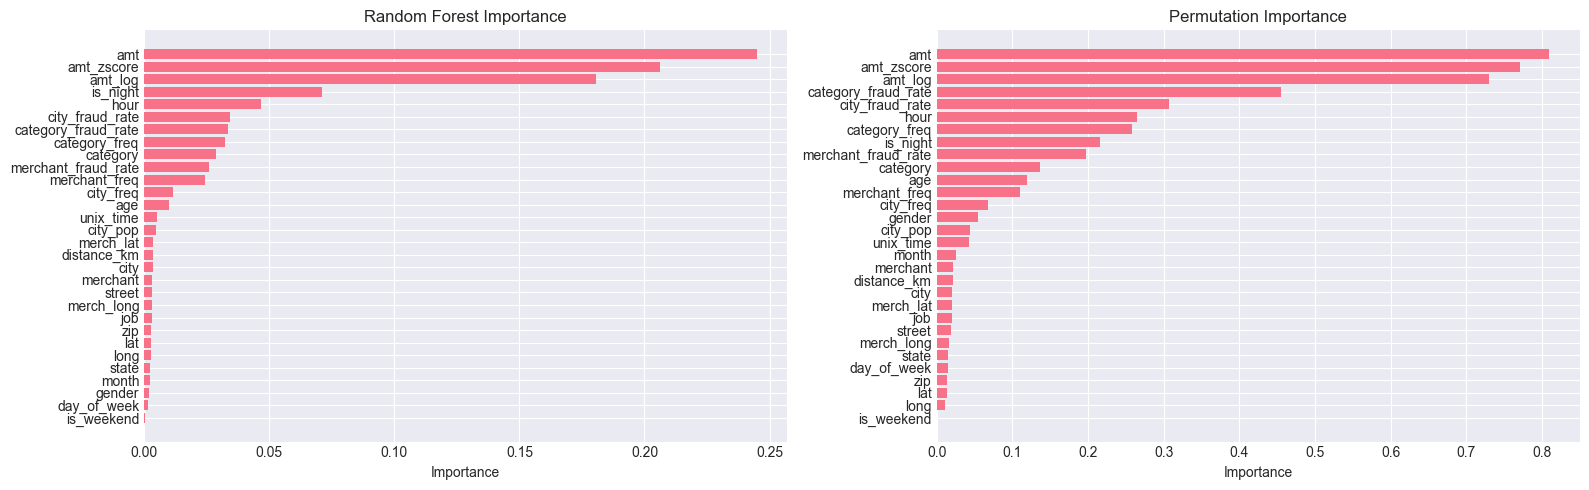

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: RF feature importance
axes[0].barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
axes[0].invert_yaxis()
axes[0].set_title("Random Forest Importance")
axes[0].set_xlabel("Importance")

# Plot 2: Permutation importance
axes[1].barh(perm_df['Feature'], perm_df['Importance'])
axes[1].invert_yaxis()
axes[1].set_title("Permutation Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

### Evaluate thresholds

In [11]:
# Evaluate thresholds
evaluate_threshold(xgb_model, X_test, y_test, 0.5, "XGBoost")
evaluate_threshold(xgb_model, X_test, y_test, 0.3, "XGBoost")
evaluate_threshold(xgb_model, X_test, y_test, 0.2, "XGBoost")


🔹 XGBoost (Threshold = 0.5)
----------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.08      0.24      0.12      2145

    accuracy                           0.99    555719
   macro avg       0.54      0.61      0.55    555719
weighted avg       0.99      0.99      0.99    555719

ROC-AUC: 0.9339045340486882
PR-AUC: 0.1408553659915077
Confusion Matrix:
[[547532   6042]
 [  1638    507]]

🔹 XGBoost (Threshold = 0.3)
----------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    553574
           1       0.08      0.33      0.13      2145

    accuracy                           0.98    555719
   macro avg       0.54      0.66      0.56    555719
weighted avg       0.99      0.98      0.99    555719

ROC-AUC: 0.9339045340486882
PR-AUC: 0.1408553659915077
Confusion Matrix:
[[545399   8175]
 [  1428

### PR Curve

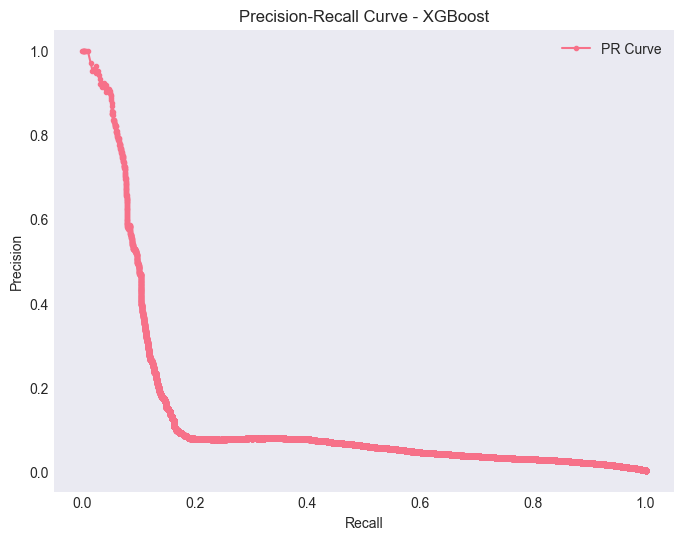

In [12]:
# Plot PR Curve
plot_PR_curve(xgb_model, X_test, y_test, name="XGBoost")